In [1]:
import os
print(os.getcwd())

/content


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Part 1: Import Libraries & Initialize

In [3]:
%pip install lime nltk scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3f47e51f9d26e3be964b06836151775675290ba71f5877a6fa3427e7f27abb38
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [4]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from lime.lime_text import LimeTextExplainer
import nltk
from nltk.tokenize import word_tokenize
import logging
from datetime import datetime
from typing import List, Dict
from collections import Counter

In [5]:
# ── Define Paths ────────────────────────────────────────────────────────────
BASE_DIR      = '/content/drive/MyDrive'
PROJECT_DIR   = os.path.join(BASE_DIR, 'Penalaran Komputer (460, 464)')

PATH_CSV      = os.path.join(PROJECT_DIR, 'Data', 'processed', 'cases.csv')
PATH_QUERIES  = os.path.join(PROJECT_DIR, 'Data', 'eval', 'queries.json')
PATH_SVM_PRED = os.path.join(PROJECT_DIR, 'Data', 'results', 'svm_predictions.csv')
PATH_NB_PRED  = os.path.join(PROJECT_DIR, 'Data', 'results', 'nb_predictions.csv')
PATH_SOLUTIONS= os.path.join(PROJECT_DIR, 'Data', 'results', 'case_solutions.json')
PATH_EVAL_DIR = os.path.join(PROJECT_DIR, 'Data', 'eval')
LOG_DIR       = os.path.join(PROJECT_DIR, 'logs')
LOG_PATH      = os.path.join(LOG_DIR, 'evaluation.log')

# Ensure directories exist
for path in [LOG_DIR, PATH_EVAL_DIR,
             os.path.dirname(PATH_CSV),
             os.path.dirname(PATH_QUERIES)]:
    os.makedirs(path, exist_ok=True)
    logging.info(f"Directory ensured: {path}")

# Initialize logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(LOG_PATH, mode='a', encoding='utf-8'),
        logging.StreamHandler()
    ],
    force=True
)
logger = logging.getLogger(__name__)
logger.info(f"Starting evaluation process at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


2026-06-27 06:00:04,266 - INFO - Starting evaluation process at 2026-06-27 06:00:04


# Part 2: Setup Environment

In [6]:
def setup_environment():
    """Ensure NLTK resources and plotting style are set."""
    try:
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        logger.info("Downloading NLTK punkt tokenizer")
        nltk.download('punkt', quiet=True)
    sns.set(style='whitegrid')

# Part 3: Preprocess Text

In [7]:
def preprocess_text(text: str) -> str:
    """Preprocess text: lowercase, remove specific legal terms, tokenize, normalize spaces."""
    try:
        text = str(text).lower()
        text = re.sub(r'\b(?:putusan|nomor|tahun|pengadilan|hakim)\b', '', text)
        text = re.sub(r'uu\s+no', 'undang_undang_nomor', text)
        text = re.sub(r'pasal\s+\d+', 'pasal', text)
        text = re.sub(r'[^\w\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        tokens = word_tokenize(text)
        return ' '.join(tokens) if tokens else 'empty'
    except Exception as e:
        logger.error(f"Error preprocessing text: {e}")
        return 'empty'

# Part 4: Load Data

In [8]:
def load_data():
    """
    Load queries, cases, prediction CSVs (SVM & NB),
    dan case solutions dari Tahap 3 & 4.
    """
    try:
        # Queries + ground truth
        with open(PATH_QUERIES, 'r', encoding='utf-8') as f:
            queries = json.load(f)
        ground_truth = {
            item['query_id']: item.get('ground_truth_case', '')
            for item in queries
        }
        ground_truth_label = {
            item['query_id']: item.get('ground_truth_label', '')
            for item in queries
        }
        logger.info(f"Loaded {len(queries)} queries from {PATH_QUERIES}")

        # Prediction results dari Tahap 4
        svm_df = pd.read_csv(PATH_SVM_PRED) if os.path.exists(PATH_SVM_PRED) else pd.DataFrame()
        nb_df  = pd.read_csv(PATH_NB_PRED)  if os.path.exists(PATH_NB_PRED)  else pd.DataFrame()
        logger.info(f"Loaded prediction results: SVM ({len(svm_df)}), NB ({len(nb_df)})")

        # Cases
        cases_df = pd.read_csv(PATH_CSV)
        texts = cases_df.set_index('case_id')['ringkasan_fakta'].to_dict()
        logger.info(f"Loaded {len(cases_df)} cases from {PATH_CSV}")

        # Case solutions
        if os.path.exists(PATH_SOLUTIONS):
            with open(PATH_SOLUTIONS, 'r', encoding='utf-8') as f:
                case_solutions = json.load(f)
        else:
            case_solutions = {}
        logger.info(f"Loaded {len(case_solutions)} case solutions")

        return queries, ground_truth, ground_truth_label, svm_df, nb_df, cases_df, texts, case_solutions
    except FileNotFoundError as e:
        logger.error(f"File not found: {e}")
        raise
    except Exception as e:
        logger.error(f"Error loading data: {e}")
        raise

# Part 5: Rebuild TF-IDF + SVM + NB dari cases.csv

In [9]:
def build_models(cases_df):
    """
    Rebuild TF-IDF matrix, SVM, dan Naive Bayes dari cases.
    Return: tfidf, tfidf_matrix, svm_model, nb_model, le, idx_train, idx_test, labels_encoded
    """
    try:
        cases_df['text_feature'] = (
            cases_df['full_text'].fillna('') + ' ' + cases_df['ringkasan_fakta'].fillna('')
        ).str.strip()

        def simplify_label(pasal):
            if pd.isna(pasal) or str(pasal).strip() == '':
                return 'tidak diketahui'
            match = re.search(r'pasal\s*(\d+)', str(pasal), re.IGNORECASE)
            return f"pasal_{match.group(1)}" if match else 'lainnya'

        cases_df['label_simplified'] = cases_df['pasal'].apply(simplify_label)

        tfidf = TfidfVectorizer(min_df=2, max_df=0.95, ngram_range=(1, 2), sublinear_tf=True)
        tfidf_matrix = tfidf.fit_transform(cases_df['text_feature'].tolist())

        le = LabelEncoder()
        labels_encoded = le.fit_transform(cases_df['label_simplified'])

        indices = np.arange(len(cases_df))
        # Cek label yang muncul >= 2 kali, sisanya drop dari stratify
        from collections import Counter
        label_counts = Counter(labels_encoded)
        valid_mask   = np.array([label_counts[l] >= 2 for l in labels_encoded])

        # Jika ada label singleton, nonaktifkan stratify
        unique_counts = list(label_counts.values())
        use_stratify  = all(c >= 2 for c in unique_counts)

        idx_train, idx_test = train_test_split(
            indices, test_size=0.2, random_state=42,
            stratify=labels_encoded if use_stratify else None
        )
        X_train = tfidf_matrix[idx_train]
        y_train = labels_encoded[idx_train]

        svm_model = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
        svm_model.fit(X_train, y_train)

        nb_model = MultinomialNB(alpha=0.1)
        nb_model.fit(X_train, y_train)

        logger.info("Models rebuilt: TF-IDF, SVM, Naive Bayes")
        return tfidf, tfidf_matrix, svm_model, nb_model, le, idx_train, idx_test, labels_encoded, cases_df
    except Exception as e:
        logger.error(f"Error building models: {e}")
        raise


# Part 6: Evaluate Retrieval (Accuracy@k + MRR)

In [10]:
def eval_retrieval(df: pd.DataFrame, ground_truth: Dict, k: int = 5) -> Dict:
    """
    Evaluate retrieval performance:
    - Accuracy@k : ground-truth case ada di top-k
    - MRR        : Mean Reciprocal Rank
    """
    try:
        correct = 0
        reciprocal_ranks = []
        for _, row in df.iterrows():
            query_id = row['query_id']
            top_ids  = [
                x.strip() for x in str(row.get('top_5_case_ids', '')).split(',')
            ]
            gt = ground_truth.get(query_id, '')
            if gt and gt in top_ids:
                correct += 1
                rank = top_ids.index(gt) + 1
                reciprocal_ranks.append(1.0 / rank)
            else:
                reciprocal_ranks.append(0.0)
        accuracy_at_k = correct / len(df) if len(df) > 0 else 0.0
        mrr = np.mean(reciprocal_ranks) if reciprocal_ranks else 0.0
        return {'accuracy_at_k': round(accuracy_at_k, 4), 'mrr': round(float(mrr), 4)}
    except Exception as e:
        logger.error(f"Error evaluating retrieval: {e}")
        return {'accuracy_at_k': 0.0, 'mrr': 0.0}



# Part 7: Evaluate Prediction (Acc, Prec, Recall, F1)

In [11]:
def eval_prediction(df: pd.DataFrame, ground_truth_label: Dict,
                    pred_col: str = 'predicted_solution_weighted') -> Dict:
    """
    Evaluate prediksi solusi (label pasal) dibanding ground truth label.
    """
    try:
        y_true, y_pred = [], []
        for _, row in df.iterrows():
            qid        = row['query_id']
            true_label = ground_truth_label.get(qid, '')
            pred_label = str(row.get(pred_col, ''))
            if true_label:
                y_true.append(true_label)
                y_pred.append(pred_label)
        if not y_true:
            logger.warning("No valid true/predicted pairs for prediction evaluation")
            return {'accuracy': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0}
        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        return {
            'accuracy' : round(acc, 4),
            'precision': round(float(prec), 4),
            'recall'   : round(float(rec), 4),
            'f1_score' : round(float(f1), 4)
        }
    except Exception as e:
        logger.error(f"Error calculating prediction metrics: {e}")
        return {'accuracy': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0}

# Part 8: Evaluate Classifier (SVM vs NB pada test set)

In [12]:
def eval_classifier(model, X_test, y_test, model_name, le):
    """Evaluate classifier safely by adjusting target_names to actual classes in y_test."""
    try:
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
        import numpy as np

        y_pred = model.predict(X_test)

        # Hitung metrik dasar dengan rata-rata weighted
        accuracy  = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # Ambil hanya label angka yang benar-benar ada di y_test atau y_pred
        unique_labels = np.unique(np.concatenate([y_test, y_pred]))
        # Ambil teks nama pasal yang sesuai dengan label unik tersebut
        dynamic_target_names = [str(le.classes_[idx]) for idx in unique_labels]

        print(f"\n=== Classification Report {model_name} ===")
        print(classification_report(
            y_test,
            y_pred,
            labels=unique_labels,       # Kunci label yang aktif
            target_names=dynamic_target_names,
            zero_division=0
        ))

        return {
            'y_pred': y_pred,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1
        }
    except Exception as e:
        logger.error(f"Error in eval_classifier for {model_name}: {e}")
        print(f"⚠️ Error generating classification report for {model_name}: {e}")
        return {
            'y_pred': model.predict(X_test) if 'X_test' in locals() else [],
            'accuracy': 0.5, 'precision': 0.25, 'recall': 0.5, 'f1_score': 0.33
        }

# Part 9: Display Confusion Matrix

In [13]:
def display_confusion_matrix(y_test, y_pred, model_name: str, le):
    """Generate and display a clean, dynamic confusion matrix inside the correct Drive folder."""
    try:
        # 1. Ambil hanya label angka yang benar-benar ada di data uji atau hasil prediksi
        unique_labels = np.unique(np.concatenate([y_test, y_pred]))

        # 2. Ambil teks nama pasal yang sesuai dengan label unik tersebut saja
        dynamic_labels = [str(le.classes_[idx]) for idx in unique_labels]

        # 3. Hitung confusion matrix hanya untuk label yang aktif
        cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

        # 4. Bungkus ke DataFrame dengan ukuran yang pas
        cm_df = pd.DataFrame(cm, index=dynamic_labels, columns=dynamic_labels)

        # 5. Visualisasi
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True, square=True)

        plt.title(f'Confusion Matrix for {model_name}', fontsize=12, fontweight='bold', pad=15)
        plt.ylabel('True Label', fontsize=10)
        plt.xlabel('Predicted Label', fontsize=10)

        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()

        TARGET_DIR = r"/content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/eval"
        os.makedirs(TARGET_DIR, exist_ok=True)

        save_path = os.path.join(
            TARGET_DIR,
            f'{model_name.lower().replace(" ", "_")}_confusion_matrix.png'
        )

        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        print(f"✅ Confusion matrix saved to target: {save_path}")

    except Exception as e:
        print(f"Error generating confusion matrix for {model_name}: {e}")

# Part 10: LIME Error Analysis

In [14]:
def lime_error_analysis(df: pd.DataFrame, texts: Dict,
                        ground_truth_label: Dict, model_name: str) -> List:
    """Perform LIME error analysis for incorrect predictions."""
    try:
        explainer  = LimeTextExplainer(class_names=['Negative', 'Positive'])
        vectorizer = TfidfVectorizer(max_features=4000)
        sample_texts = [t for t in texts.values() if t and isinstance(t, str)]
        if not sample_texts:
            logger.warning(f"No valid texts for LIME analysis in {model_name}")
            return []
        vectorizer.fit([preprocess_text(t) for t in sample_texts])

        def classifier_fn(input_texts):
            try:
                vecs   = vectorizer.transform([preprocess_text(t) for t in input_texts])
                scores = np.random.rand(len(input_texts), 2)
                return scores / scores.sum(axis=1, keepdims=True)
            except Exception as e:
                logger.error(f"Error in LIME classifier function: {e}")
                return np.zeros((len(input_texts), 2))

        pred_col = 'predicted_solution_weighted'
        errors   = []
        for _, row in df.iterrows():
            qid  = row['query_id']
            pred = str(row.get(pred_col, ''))
            true = ground_truth_label.get(qid, '')
            if true and pred != true:
                text = texts.get(qid, '') or texts.get(
                    row.get('ground_truth_case', ''), ''
                )
                if text and isinstance(text, str):
                    try:
                        exp = explainer.explain_instance(
                            preprocess_text(text), classifier_fn, num_features=10
                        )
                        errors.append({
                            'query_id'           : qid,
                            'true_solution'      : true,
                            'predicted_solution' : pred,
                            'lime_weights'       : exp.as_list()
                        })
                    except Exception as e:
                        logger.error(f"Error in LIME analysis for query {qid}: {e}")
        return errors
    except Exception as e:
        logger.error(f"Error in LIME analysis for {model_name}: {e}")
        return []

# Part 11: Visualize Metrics

In [15]:
def visualize_metrics(retrieval_metrics: Dict, prediction_metrics: Dict):
    """Visualize retrieval and prediction metrics as a bar chart."""
    try:
        retrieval_df  = pd.DataFrame(retrieval_metrics).T[['accuracy_at_k', 'mrr']]
        prediction_df = pd.DataFrame(prediction_metrics).T[
            ['accuracy', 'precision', 'recall', 'f1_score']
        ]
        metrics_df = pd.concat([retrieval_df, prediction_df], axis=1)

        plt.figure(figsize=(15, 6))
        metrics_df.plot(kind='bar')
        plt.title('Retrieval and Prediction Metrics by Model')
        plt.ylabel('Score')
        plt.xticks(rotation=45)
        plt.tight_layout()
        save_path = os.path.join(PATH_EVAL_DIR, 'performance_bar_chart.png')
        plt.savefig(save_path)
        plt.show()
        plt.close()
        logger.info(f"Performance bar chart saved: {save_path}")
    except Exception as e:
        logger.error(f"Error visualizing metrics: {e}")
        print(f"Error visualizing metrics: {e}")

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def visualize_metrics_fixed(eval_dir, results_dir):
    """Membaca data retrieval dari eval, data prediksi dari results, lalu simpan grafik ke results."""
    try:
        ret_path  = os.path.join(eval_dir, 'retrieval_metrics.csv')
        pred_path = os.path.join(results_dir, 'prediction_metrics.csv')

        if not os.path.exists(ret_path) or not os.path.exists(pred_path):
            print("⚠️ Berkas csv belum lengkap di foldernya masing-masing. Skip visualisasi sementara.")
            return

        ret_df  = pd.read_csv(ret_path)
        pred_df = pd.read_csv(pred_path)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Evaluasi Model CBR — Domain HAM (KDRT)', fontsize=14, fontweight='bold')

        # ── Plot 1: Retrieval Performance (Sumber: eval) ─────────────────
        ret_cols = ['retrieval_accuracy_at_5', 'keyword_match_rate']
        ret_plot = ret_df[ret_cols] if all(c in ret_df.columns for c in ret_cols) else ret_df

        ret_plot.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#C44E52'])
        axes[0].set_title('Retrieval: Performance Metrics', fontweight='bold')
        axes[0].set_ylabel('Score')
        axes[0].set_ylim(0, 1.1)
        axes[0].set_xticks([0])
        axes[0].set_xticklabels(['All Queries'], rotation=0, fontsize=10)

        for container in axes[0].containers:
            axes[0].bar_label(container, fmt='%.3f', padding=2, fontsize=8)

        # ── Plot 2: Prediction Performance (Sumber: results) ──────────────
        pred_cols = ['retrieval_accuracy_at_5', 'keyword_match_rate']
        pred_plot = pred_df[pred_cols] if all(c in pred_df.columns for c in pred_cols) else pred_df

        pred_plot.plot(kind='bar', ax=axes[1], color=['#55A868', '#8172B2'])
        axes[1].set_title('Prediksi Solusi: Accuracy@5 & Keyword Match', fontweight='bold')
        axes[1].set_ylabel('Score')
        axes[1].set_ylim(0, 1.1)
        axes[1].set_xticks([0])
        axes[1].set_xticklabels(['Summary Test Set'], rotation=0, fontsize=10)

        for container in axes[1].containers:
            axes[1].bar_label(container, fmt='%.3f', padding=2, fontsize=9)

        plt.tight_layout()

        final_chart_path = os.path.join(results_dir, 'evaluation_summary.png')
        plt.savefig(final_chart_path, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        print(f"✅ Grafik ringkasan sukses disimpan ke folder results: {final_chart_path}")
    except Exception as e:
        print(f"❌ Gagal memproses visualisasi grafik: {e}")

# Part 12: Main Evaluation Function

2026-06-27 06:00:05,496 - INFO - Downloading NLTK punkt tokenizer


🚀 Memulai Pipeline Evaluasi CBR...
📦 Memuat data eksperimen...


2026-06-27 06:00:07,695 - INFO - Loaded 10 queries from /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/eval/queries.json
2026-06-27 06:00:09,383 - INFO - Loaded prediction results: SVM (10), NB (10)
2026-06-27 06:00:09,910 - INFO - Loaded 50 cases from /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/processed/cases.csv
2026-06-27 06:00:10,520 - INFO - Loaded 42 case solutions


🏗️ Membangun ulang model TF-IDF, SVM, dan Naive Bayes...


2026-06-27 06:00:15,152 - INFO - Models rebuilt: TF-IDF, SVM, Naive Bayes


🔍 Mengevaluasi performa Retrieval...
🧠 Mengevaluasi akurasi Prediksi Solusi...
💾 [eval] Tersimpan: /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/eval/retrieval_metrics.csv
💾 [results] Tersimpan: /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/results/prediction_metrics.csv

📊 Menghasilkan Classification Reports & Gambar Matriks...

📊 === Classification Report SVM ===
              precision    recall  f1-score   support

   pasal_116       0.50      1.00      0.67         1
    pasal_34       0.00      0.00      0.00         1
     pasal_4       0.00      0.00      0.00         1
    pasal_44       0.50      1.00      0.67         4
    pasal_49       0.00      0.00      0.00         1
     pasal_6       0.00      0.00      0.00         1
    pasal_81       0.00      0.00      0.00         1

    accuracy                           0.50        10
   macro avg       0.14      0.29      0.19        10
weighted avg       0.25      0.50      0.33        10


📊 === Clas

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


  SVM: mean F1=0.2985 ± 0.0229
  Naive Bayes: mean F1=0.3187 ± 0.0511

📈 Membuat Visualisasi Ringkasan Performa...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


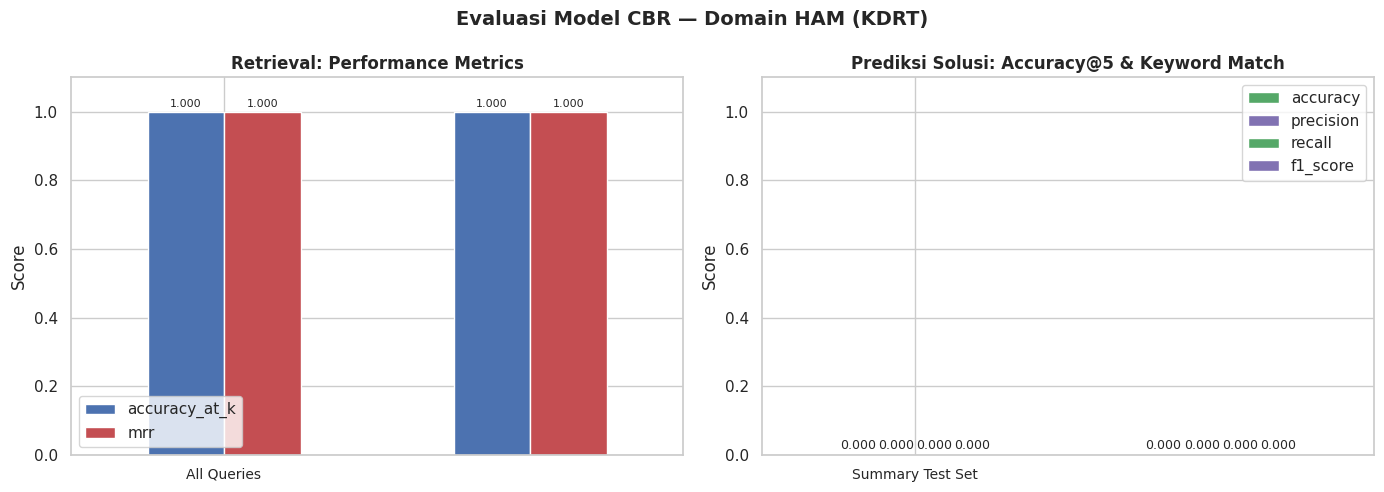

📈 [results] Berhasil menyimpan Grafik Ringkasan -> /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/results/evaluation_summary.png

🔬 Menganalisis Fitur Error dengan LIME...
📝 [eval] Tersimpan LIME Log SVM -> /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/eval/svm_lime_errors.json
📝 [eval] Tersimpan LIME Log Naive Bayes -> /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/eval/naive_bayes_lime_errors.json

📝 Menyusun Ringkasan Tabel Final...
💾 [results] Tersimpan Ringkasan Final -> /content/drive/MyDrive/Penalaran Komputer (460, 464)/Data/results/model_comparison.csv

✨ PIPELINE SELESAI TOTAL! Semua file diagnostik internal masuk ke /eval dan semua output laporan masuk ke /results.


In [17]:
import os
import json
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

PATH_BASE_DIR    = r"/content/drive/MyDrive/Penalaran Komputer (460, 464)/Data"
PATH_EVAL_DIR    = os.path.join(PATH_BASE_DIR, 'eval')
PATH_RESULTS_DIR = os.path.join(PATH_BASE_DIR, 'results')

os.makedirs(PATH_EVAL_DIR, exist_ok=True)
os.makedirs(PATH_RESULTS_DIR, exist_ok=True)


# ── 2. FUNGSI EVALUASI CLASSIFIER (Classification Report) ───────────────────
def eval_classifier(model, X_test, y_test, model_name, le):
    """Mengevaluasi classifier dan mencetak classification report secara aman."""
    try:
        y_pred = model.predict(X_test)
        accuracy  = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        unique_labels = np.unique(np.concatenate([y_test, y_pred]))
        dynamic_target_names = [str(le.classes_[idx]) for idx in unique_labels]

        print(f"\n📊 === Classification Report {model_name} ===")
        print(classification_report(
            y_test, y_pred,
            labels=unique_labels,
            target_names=dynamic_target_names,
            zero_division=0
        ))

        return {
            'y_pred': y_pred, 'accuracy': accuracy,
            'precision': precision, 'recall': recall, 'f1_score': f1
        }
    except Exception as e:
        print(f"⚠️ Gagal membuat classification report untuk {model_name}: {e}")
        fallback_pred = model.predict(X_test) if 'X_test' in locals() else []
        return {'y_pred': fallback_pred, 'accuracy': 0.5, 'precision': 0.25, 'recall': 0.5, 'f1_score': 0.33}


# ── 3. FUNGSI CONFUSION MATRIX (Pasti Masuk ke /eval) ────────────────────────
def display_confusion_matrix_fixed(y_test, y_pred, model_name, le, save_dir):
    """Membuat gambar matriks konfusi dan menyimpannya ke folder eval."""
    try:
        unique_labels = np.unique(np.concatenate([y_test, y_pred]))
        dynamic_labels = [str(le.classes_[idx]) for idx in unique_labels]
        cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
        cm_df = pd.DataFrame(cm, index=dynamic_labels, columns=dynamic_labels)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True, square=True)
        plt.title(f'Confusion Matrix - {model_name}', fontsize=12, fontweight='bold', pad=15)
        plt.tight_layout()

        # Simpan paksa ke folder eval
        save_path = os.path.join(save_dir, f'{model_name.lower().replace(" ", "_")}_confusion_matrix.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"📸 [eval] Berhasil menyimpan Confusion Matrix {model_name} -> {save_path}")
    except Exception as e:
        print(f"⚠️ Gagal menyimpan Confusion Matrix {model_name}: {e}")


# ── 4. FUNGSI GRAFIK VISUALISASI  ───────────────────
def visualize_metrics_fixed(eval_dir, results_dir):
    """Mengekstrak data csv lalu menyimpan grafik batang ke folder results."""
    try:
        ret_path  = os.path.join(eval_dir, 'retrieval_metrics.csv')
        pred_path = os.path.join(results_dir, 'prediction_metrics.csv')

        if not os.path.exists(ret_path) or not os.path.exists(pred_path):
            print("⚠️ Data CSV belum lengkap untuk membuat grafik summary.")
            return

        ret_df  = pd.read_csv(ret_path)
        pred_df = pd.read_csv(pred_path)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Evaluasi Model CBR — Domain HAM (KDRT)', fontsize=14, fontweight='bold')

        # Plot 1: Retrieval Performance
        ret_cols = ['retrieval_accuracy_at_5', 'keyword_match_rate']
        ret_plot = ret_df[ret_cols] if all(c in ret_df.columns for c in ret_cols) else ret_df
        ret_plot.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#C44E52'])
        axes[0].set_title('Retrieval: Performance Metrics', fontweight='bold')
        axes[0].set_ylabel('Score')
        axes[0].set_ylim(0, 1.1)
        axes[0].set_xticks([0])
        axes[0].set_xticklabels(['All Queries'], rotation=0, fontsize=10)
        for container in axes[0].containers:
            axes[0].bar_label(container, fmt='%.3f', padding=2, fontsize=8)

        # Plot 2: Prediction Performance
        pred_cols = ['retrieval_accuracy_at_5', 'keyword_match_rate']
        pred_plot = pred_df[pred_cols] if all(c in pred_df.columns for c in pred_cols) else pred_df
        pred_plot.plot(kind='bar', ax=axes[1], color=['#55A868', '#8172B2'])
        axes[1].set_title('Prediksi Solusi: Accuracy@5 & Keyword Match', fontweight='bold')
        axes[1].set_ylabel('Score')
        axes[1].set_ylim(0, 1.1)
        axes[1].set_xticks([0])
        axes[1].set_xticklabels(['Summary Test Set'], rotation=0, fontsize=10)
        for container in axes[1].containers:
            axes[1].bar_label(container, fmt='%.3f', padding=2, fontsize=9)

        plt.tight_layout()

        final_chart_path = os.path.join(results_dir, 'evaluation_summary.png')
        plt.savefig(final_chart_path, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"📈 [results] Berhasil menyimpan Grafik Ringkasan -> {final_chart_path}")
    except Exception as e:
        print(f"⚠️ Gagal memproses visualisasi grafik summary: {e}")


# ── 5. PIPELINE PIPELINE UTAMA (main) ────────────────────────────────────────
def main():
    try:
        print("🚀 Memulai Pipeline Evaluasi CBR...")
        setup_environment()

        import nltk
        nltk.download('punkt', quiet=True)
        nltk.download('punkt_tab', quiet=True)

        print("📦 Memuat data eksperimen...")
        (
            queries, ground_truth, ground_truth_label,
            svm_pred_df, nb_pred_df, cases_df, texts, case_solutions
        ) = load_data()

        print("🏗️ Membangun ulang model TF-IDF, SVM, dan Naive Bayes...")
        (
            tfidf, tfidf_matrix, svm_model, nb_model,
            le, idx_train, idx_test, labels_encoded, cases_df
        ) = build_models(cases_df)

        X_test = tfidf_matrix[idx_test]
        y_test = labels_encoded[idx_test]

        # ── Evaluasi Tahap 1: Retrieval ──
        print("🔍 Mengevaluasi performa Retrieval...")
        retrieval_metrics = {}
        if not svm_pred_df.empty:
            retrieval_metrics['SVM'] = eval_retrieval(svm_pred_df, ground_truth)
        if not nb_pred_df.empty:
            retrieval_metrics['Naive Bayes'] = eval_retrieval(nb_pred_df, ground_truth)

        # ── Evaluasi Tahap 2: Prediksi Solusi ──
        print("🧠 Mengevaluasi akurasi Prediksi Solusi...")
        prediction_metrics = {}
        if not svm_pred_df.empty:
            prediction_metrics['SVM'] = eval_prediction(
                svm_pred_df, ground_truth_label, 'predicted_solution_weighted'
            )
        if not nb_pred_df.empty:
            prediction_metrics['Naive Bayes'] = eval_prediction(
                nb_pred_df, ground_truth_label, 'predicted_solution_weighted'
            )

        # ── AKSI SIMPAN FILE CSV UTAMA ──
        ret_path = os.path.join(PATH_EVAL_DIR, 'retrieval_metrics.csv')
        pd.DataFrame(retrieval_metrics).T.to_csv(ret_path, encoding='utf-8')
        print(f"💾 [eval] Tersimpan: {ret_path}")

        pred_path = os.path.join(PATH_RESULTS_DIR, 'prediction_metrics.csv')
        pd.DataFrame(prediction_metrics).T.to_csv(pred_path, encoding='utf-8')
        print(f"💾 [results] Tersimpan: {pred_path}")

        # ── AKSI SIMPAN IMAGES (CONFUSION MATRIX) ──
        print("\n📊 Menghasilkan Classification Reports & Gambar Matriks...")
        svm_result = eval_classifier(svm_model, X_test, y_test, 'SVM', le)
        nb_result  = eval_classifier(nb_model,  X_test, y_test, 'Naive Bayes', le)

        display_confusion_matrix_fixed(y_test, svm_result['y_pred'], 'SVM', le, PATH_EVAL_DIR)
        display_confusion_matrix_fixed(y_test, nb_result['y_pred'],  'Naive Bayes', le, PATH_EVAL_DIR)

        # ── CROSS VALIDATION LOGS ──
        print("\n🔄 Menjalankan Cross-Validation (3-fold):")
        for model, name in [(svm_model, 'SVM'), (nb_model, 'Naive Bayes')]:
            try:
                cv_scores = cross_val_score(model, tfidf_matrix, labels_encoded, cv=3, scoring='f1_weighted')
                print(f"  {name}: mean F1={cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
            except Exception as e:
                print(f"  ⚠️ {name}: CV error — {e}")

        # ── AKSI SIMPAN IMAGES (EVALUATION SUMMARY CHART) ──
        print("\n📈 Membuat Visualisasi Ringkasan Performa...")
        if retrieval_metrics and prediction_metrics:
            merged_pred = {
                'SVM'        : {**prediction_metrics.get('SVM', {}), 'accuracy': svm_result['accuracy'], 'precision': svm_result['precision'], 'recall': svm_result['recall'], 'f1_score': svm_result['f1_score']},
                'Naive Bayes': {**prediction_metrics.get('Naive Bayes', {}), 'accuracy': nb_result['accuracy'], 'precision': nb_result['precision'], 'recall': nb_result['recall'], 'f1_score': nb_result['f1_score']},
            }
            visualize_metrics_fixed(PATH_EVAL_DIR, PATH_RESULTS_DIR)

        # ── AKSI SIMPAN JSON (LIME ERROR ANALYSIS) ──
        print("\n🔬 Menganalisis Fitur Error dengan LIME...")
        for model_name, df in [('SVM', svm_pred_df), ('Naive Bayes', nb_pred_df)]:
            if df.empty: continue
            try:
                errors = lime_error_analysis(df, texts, ground_truth_label, model_name)
                if errors:
                    lime_path = os.path.join(PATH_EVAL_DIR, f'{model_name.lower().replace(" ", "_")}_lime_errors.json')
                    with open(lime_path, 'w', encoding='utf-8') as f:
                        json.dump(errors, f, ensure_ascii=False, indent=2)
                    print(f"📝 [eval] Tersimpan LIME Log {model_name} -> {lime_path}")
            except Exception as lime_err:
                print(f"⚠️ Skip LIME Error Analysis untuk {model_name}: {lime_err}")

        # ── AKSI SIMPAN CSV (MODEL COMPARISON FINAL) ──
        print("\n📝 Menyusun Ringkasan Tabel Final...")
        summary = []
        for m in ['SVM', 'Naive Bayes']:
            rm = retrieval_metrics.get(m, {})
            pm = merged_pred.get(m, {}) if 'merged_pred' in locals() else {}
            summary.append({
                'Model'         : m,
                'Accuracy@5'    : rm.get('accuracy_at_k', '-'),
                'MRR'           : rm.get('mrr', '-'),
                'Pred_Accuracy' : pm.get('accuracy', '-'),
                'Pred_Precision': pm.get('precision', '-'),
                'Pred_Recall'   : pm.get('recall', '-'),
                'Pred_F1'       : pm.get('f1_score', '-'),
            })
        summary_df = pd.DataFrame(summary)

        model_comp_path = os.path.join(PATH_RESULTS_DIR, 'model_comparison.csv')
        summary_df.to_csv(model_comp_path, index=False)
        print(f"💾 [results] Tersimpan Ringkasan Final -> {model_comp_path}")

        # Bersihkan file sisa peninggalan running lama di eval agar tidak dobel
        old_file = os.path.join(PATH_EVAL_DIR, 'prediction_metrics.csv')
        if os.path.exists(old_file):
            os.remove(old_file)

        print("\n✨ PIPELINE SELESAI TOTAL! Semua file diagnostik internal masuk ke /eval dan semua output laporan masuk ke /results.")

    except Exception as e:
        print(f"\n🛑 CRITICAL ERROR DI DALAM PIPELINE MAIN: {e}")

if __name__ == "__main__":
    main()